# 02 — Exploratory Data Analysis

**Project:** Enterprise Marketing Analytics & Customer 360 Platform  
**Data source:** `data/processed/olist_analytics.duckdb` (real KPI views)  
**Status:** Complete — all metrics from live SQL views

## Business Questions
1. What are the main revenue trends over time?
2. Which product categories drive the most revenue?
3. Which customer segments are most valuable?
4. What is the repeat purchase rate?
5. Which regions/customers/products have the highest business impact?
6. How do delivery performance and review scores affect customer experience?
7. Which KPIs should executives track weekly?

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path('..').resolve()
DB_PATH = PROJECT_ROOT / 'data' / 'processed' / 'olist_analytics.duckdb'
EXPORT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'dashboard_exports'
CHART_DIR = PROJECT_ROOT / 'dashboards' / 'screenshots'

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 120, 'font.size': 11})

conn = duckdb.connect(str(DB_PATH), read_only=True)

def q(sql: str) -> pd.DataFrame:
    """Run SQL against the analytics database and return a DataFrame."""
    return conn.execute(sql).fetchdf()

print(f'Database: {DB_PATH}')
print(f'Chart exports: {CHART_DIR}')
print(f'CSV exports: {EXPORT_DIR}')

Database: /Users/angollapraveengoud/Desktop/enterprise-marketing-analytics-platform/data/processed/olist_analytics.duckdb
Chart exports: /Users/angollapraveengoud/Desktop/enterprise-marketing-analytics-platform/dashboards/screenshots
CSV exports: /Users/angollapraveengoud/Desktop/enterprise-marketing-analytics-platform/data/processed/dashboard_exports


## Executive KPI Snapshot

In [2]:
kpi = q('SELECT * FROM kpi_executive_snapshot')
kpi_display = kpi.T.rename(columns={0: 'value'})
kpi_display.index = [
    'Total Revenue (BRL)', 'Total Orders', 'Total Customers',
    'Average Order Value (BRL)', 'Repeat Purchase Rate (%)',
    'Avg Review Score', 'Delivery Delay Rate (%)'
]
kpi_display

,value
Total Revenue (BRL),13221498.11
Total Orders,96478.00
Total Customers,93358.00
Average Order Value (BRL),137.04
Repeat Purchase Rate (%),3.00
Avg Review Score,4.09
Delivery Delay Rate (%),6.77


## Q1 — Revenue trends over time

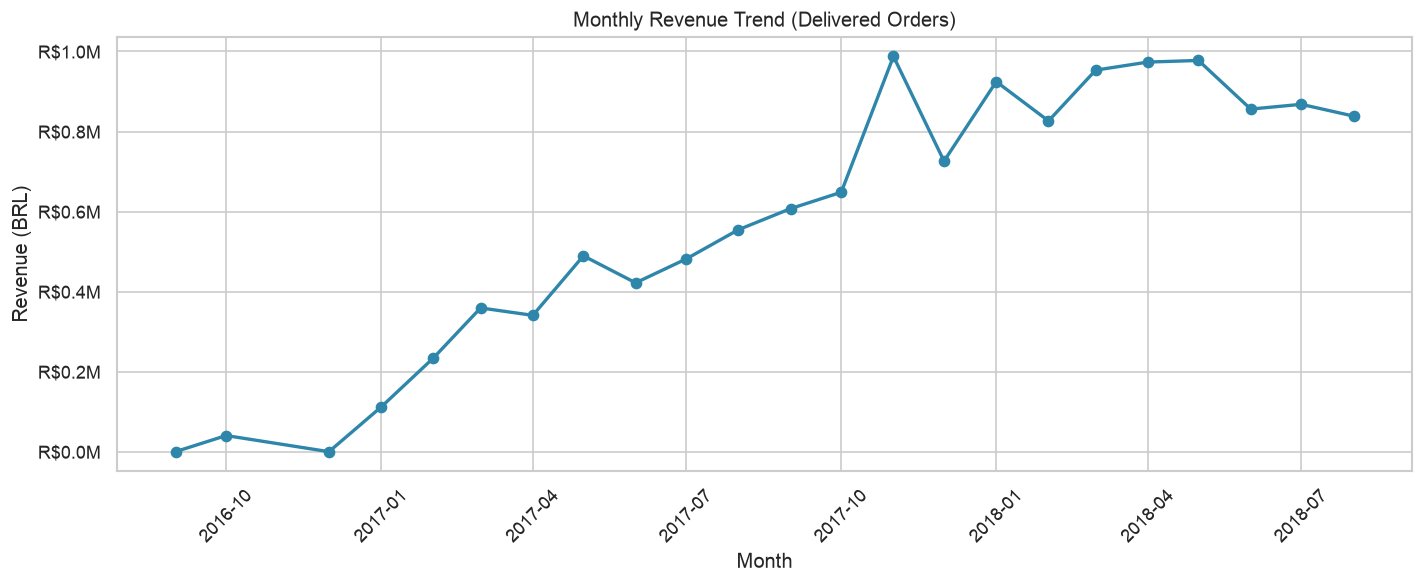

First month: September 2016 — R$134.97
Peak month:  November 2017 — R$987,765.37
Last month:  August 2018 — R$838,576.64


In [3]:
revenue_month = q('SELECT * FROM kpi_revenue_by_month ORDER BY year, month')
revenue_month['period'] = pd.to_datetime(
    revenue_month['year'].astype(str) + '-' + revenue_month['month'].astype(str).str.zfill(2) + '-01'
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(revenue_month['period'], revenue_month['revenue'], marker='o', linewidth=2, color='#2E86AB')
ax.set_title('Monthly Revenue Trend (Delivered Orders)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / 'revenue_trend.png', bbox_inches='tight')
plt.show()

first = revenue_month.iloc[0]
peak = revenue_month.loc[revenue_month['revenue'].idxmax()]
last = revenue_month.iloc[-1]
print(f"First month: {first['month_name']} {int(first['year'])} — R${first['revenue']:,.2f}")
print(f"Peak month:  {peak['month_name']} {int(peak['year'])} — R${peak['revenue']:,.2f}")
print(f"Last month:  {last['month_name']} {int(last['year'])} — R${last['revenue']:,.2f}")

## Q2 — Product categories driving revenue

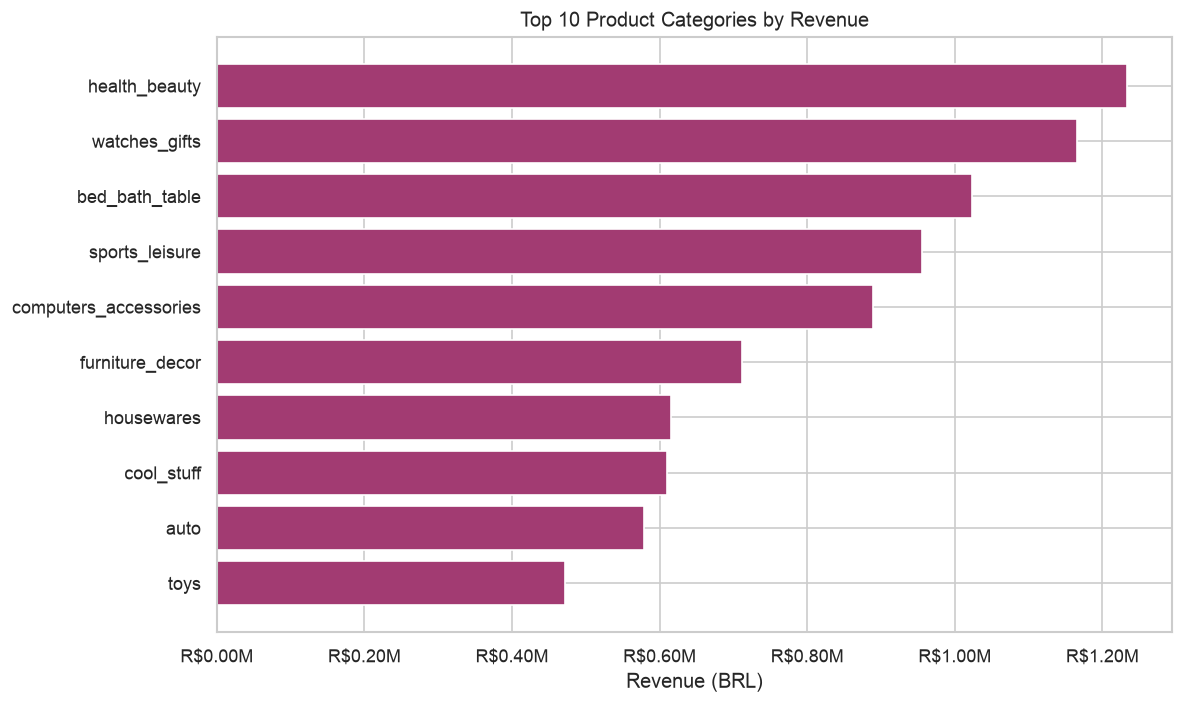

Top 5 categories:


,category_en,revenue,order_count
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530


Top 5 categories account for 39.8% of total category revenue.


In [4]:
categories = q('SELECT * FROM kpi_revenue_by_category ORDER BY revenue DESC')
top10 = categories.head(10).sort_values('revenue')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['category_en'], top10['revenue'], color='#A23B72')
ax.set_title('Top 10 Product Categories by Revenue')
ax.set_xlabel('Revenue (BRL)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.2f}M'))
plt.tight_layout()
plt.savefig(CHART_DIR / 'revenue_by_category.png', bbox_inches='tight')
plt.show()

top5_share = categories.head(5)['revenue'].sum() / categories['revenue'].sum() * 100
print('Top 5 categories:')
display(categories.head(5))
print(f"Top 5 categories account for {top5_share:.1f}% of total category revenue.")

## Q3 — Customer segment value (RFM)

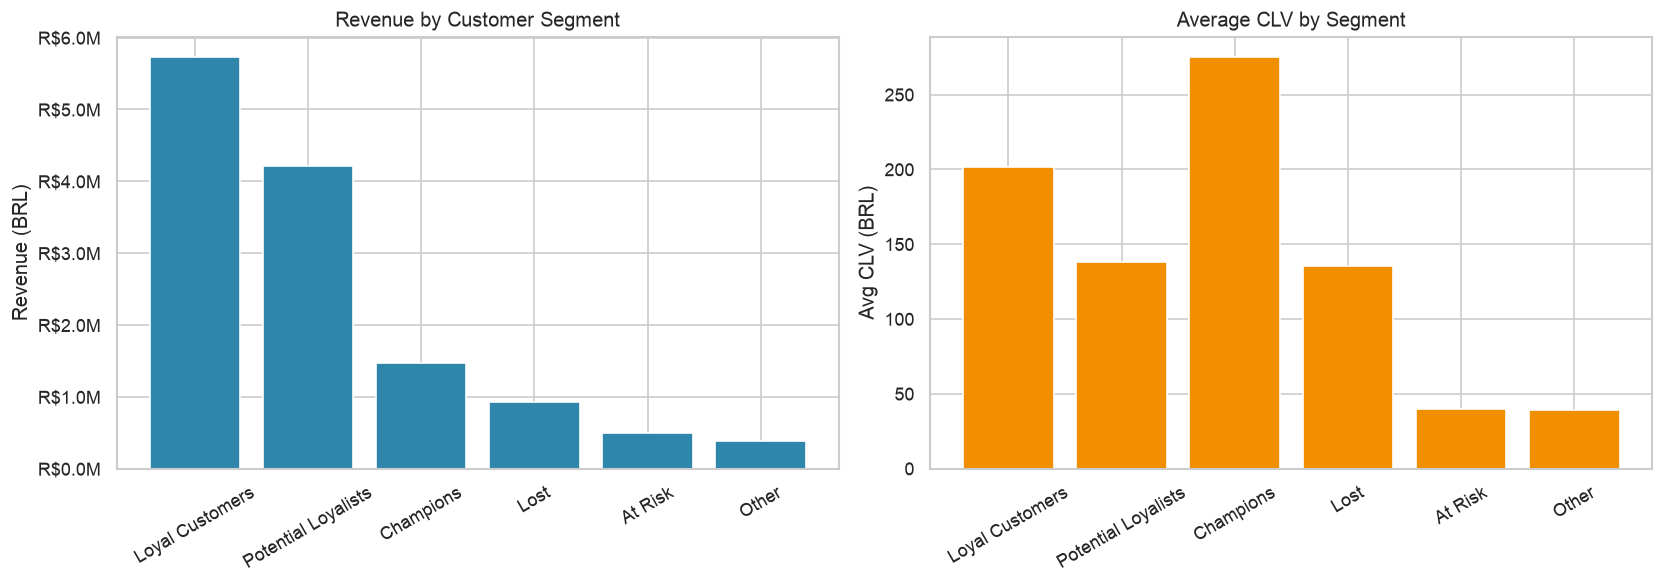

,segment_name,customer_count,avg_clv,total_revenue,avg_frequency,avg_recency_days
0,Loyal Customers,28403,201.63,5726982.21,1.1,324.0
1,Potential Loyalists,30461,138.27,4211901.32,1.0,101.0
2,Champions,5325,275.09,1464840.23,1.2,139.0
3,Lost,6898,135.24,932909.33,1.0,337.0
4,At Risk,12499,40.19,502317.66,1.0,409.0
5,Other,9810,39.00,382547.36,1.0,174.0


In [5]:
segments = q('SELECT * FROM vw_segment_summary ORDER BY total_revenue DESC')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(segments['segment_name'], segments['total_revenue'], color='#2E86AB')
axes[0].set_title('Revenue by Customer Segment')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

axes[1].bar(segments['segment_name'], segments['avg_clv'], color='#F18F01')
axes[1].set_title('Average CLV by Segment')
axes[1].set_ylabel('Avg CLV (BRL)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(CHART_DIR / 'customer_segments.png', bbox_inches='tight')
plt.show()

display(segments)

## Q4 — Repeat purchase rate

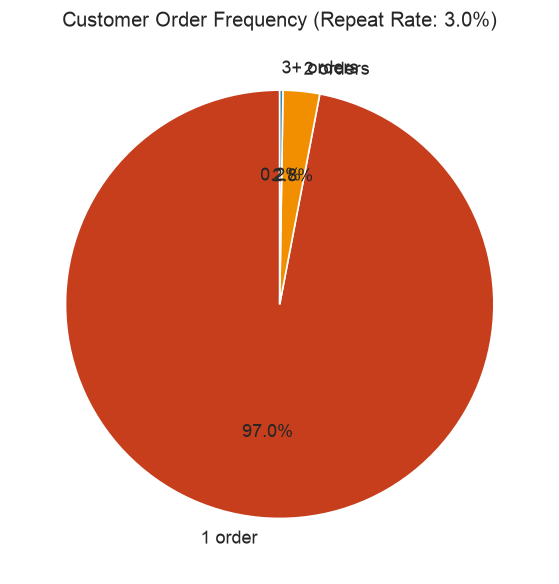

Repeat purchase rate: 3.0% of customers placed 2+ delivered orders


,order_bucket,customers
0,1 order,90557
1,2 orders,2573
2,3+ orders,228


In [6]:
repeat = q('SELECT * FROM kpi_repeat_purchase_rate')
repeat_pct = repeat['repeat_purchase_rate_pct'].iloc[0]

order_dist = q("""
    SELECT
        CASE
            WHEN order_count = 1 THEN '1 order'
            WHEN order_count = 2 THEN '2 orders'
            ELSE '3+ orders'
        END AS order_bucket,
        COUNT(*) AS customers
    FROM (
        SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
        FROM customers c
        INNER JOIN orders o ON c.customer_id = o.customer_id
        WHERE o.is_delivered = 1
        GROUP BY c.customer_unique_id
    ) t
    GROUP BY 1
    ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#C73E1D', '#F18F01', '#2E86AB']
ax.pie(order_dist['customers'], labels=order_dist['order_bucket'], autopct='%1.1f%%',
       colors=colors, startangle=90)
ax.set_title(f'Customer Order Frequency (Repeat Rate: {repeat_pct}%)')
plt.tight_layout()
plt.savefig(CHART_DIR / 'repeat_purchase_rate.png', bbox_inches='tight')
plt.show()

print(f'Repeat purchase rate: {repeat_pct}% of customers placed 2+ delivered orders')
display(order_dist)

## Q5 — Regional business impact

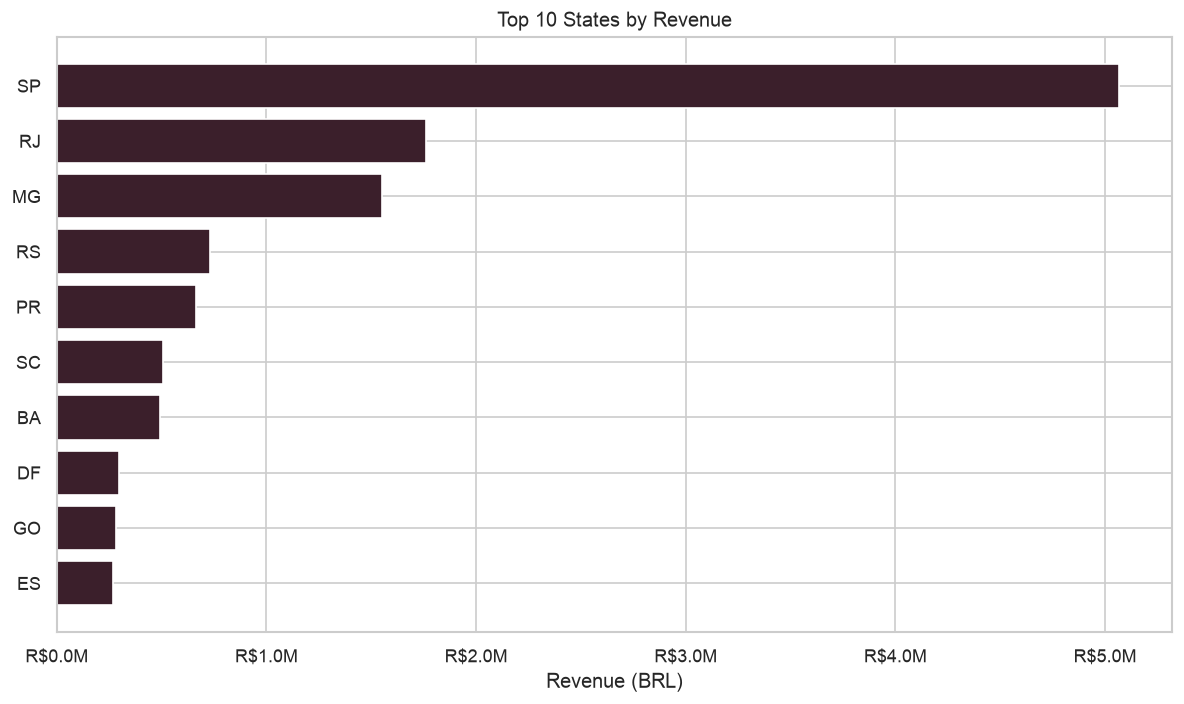

São Paulo (SP) alone drives 38.3% of total state revenue.


,customer_state,revenue,order_count,customer_count
0,SP,5067633.16,40501,39156
1,RJ,1759651.13,12350,11917
2,MG,1552481.83,11354,11001
3,RS,728897.47,5345,5168
4,PR,666063.51,4923,4769


In [7]:
states = q('SELECT * FROM vw_revenue_by_state ORDER BY revenue DESC')
top10_states = states.head(10).sort_values('revenue')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_states['customer_state'], top10_states['revenue'], color='#3B1F2B')
ax.set_title('Top 10 States by Revenue')
ax.set_xlabel('Revenue (BRL)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(CHART_DIR / 'revenue_by_state.png', bbox_inches='tight')
plt.show()

sp_share = states.loc[states['customer_state'] == 'SP', 'revenue'].iloc[0] / states['revenue'].sum() * 100
print(f'São Paulo (SP) alone drives {sp_share:.1f}% of total state revenue.')
display(states.head(5))

## Q6 — Delivery performance & review scores

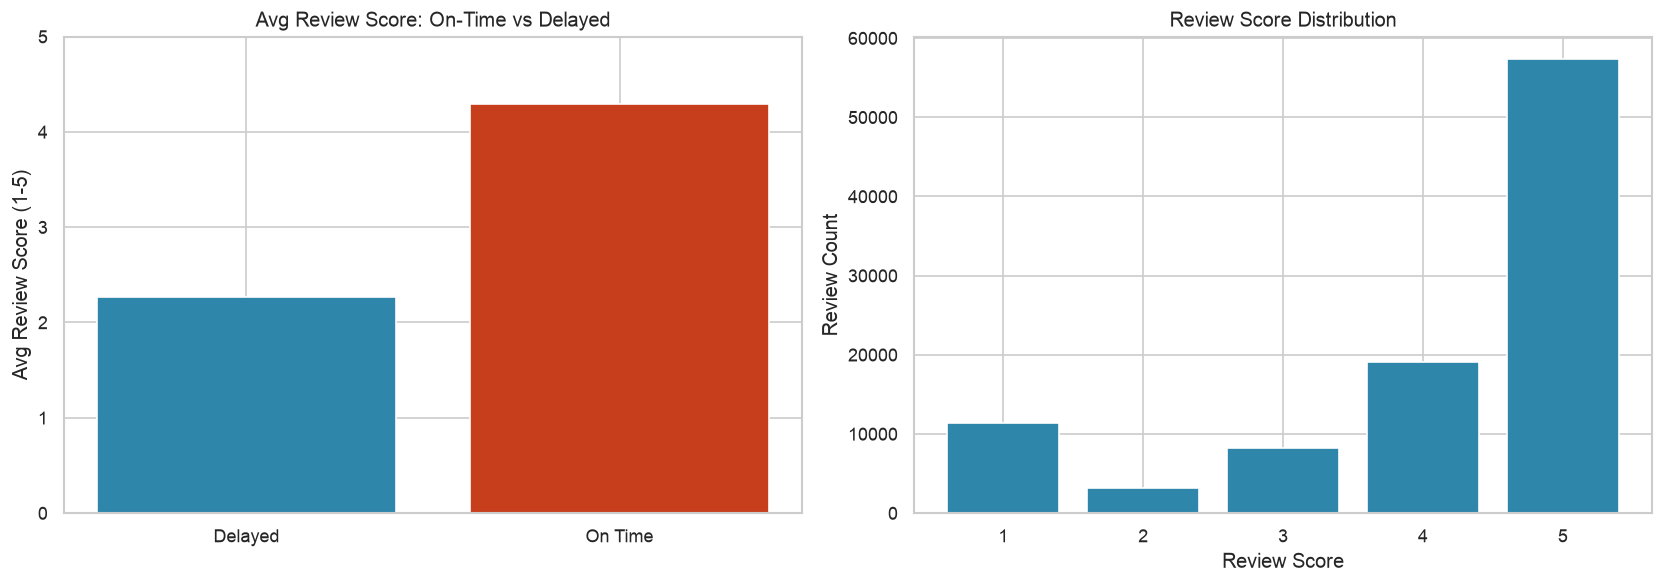

Delivery delay rate: 6.77%


,delay_bucket,avg_review_score,review_count
0,Delayed,2.27,6409
1,On Time,4.29,89952


In [8]:
delay_review = q('SELECT * FROM vw_delay_vs_review')
review_dist = q('SELECT * FROM vw_review_summary ORDER BY review_score')
delay_rate = q('SELECT * FROM kpi_delivery_delay_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(delay_review['delay_bucket'], delay_review['avg_review_score'],
            color=['#2E86AB', '#C73E1D'])
axes[0].set_title('Avg Review Score: On-Time vs Delayed')
axes[0].set_ylabel('Avg Review Score (1-5)')
axes[0].set_ylim(0, 5)

axes[1].bar(review_dist['review_score'], review_dist['review_count'], color='#2E86AB')
axes[1].set_title('Review Score Distribution')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Review Count')

plt.tight_layout()
plt.savefig(CHART_DIR / 'delivery_and_reviews.png', bbox_inches='tight')
plt.show()

print(f"Delivery delay rate: {delay_rate['delivery_delay_rate_pct'].iloc[0]}%")
display(delay_review)

## Q7 — Monthly delivery delay trend

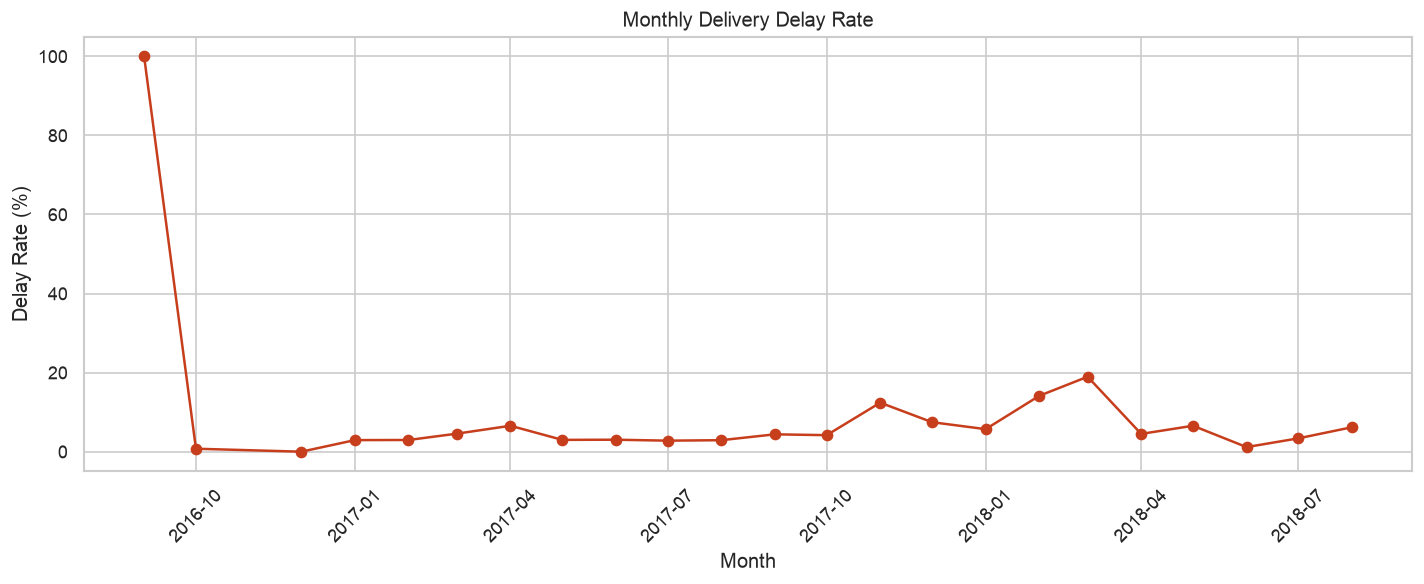

In [9]:
delivery_month = q('SELECT * FROM vw_delivery_performance ORDER BY year, month')
delivery_month['period'] = pd.to_datetime(
    delivery_month['year'].astype(str) + '-' + delivery_month['month'].astype(str).str.zfill(2) + '-01'
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(delivery_month['period'], delivery_month['delay_rate_pct'], marker='o', color='#C73E1D')
ax.set_title('Monthly Delivery Delay Rate')
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / 'delivery_delay_trend.png', bbox_inches='tight')
plt.show()

## Export dashboard-ready CSVs for Power BI

In [10]:
DASHBOARD_VIEWS = [
    'kpi_executive_snapshot',
    'kpi_revenue_by_month',
    'kpi_revenue_by_category',
    'vw_segment_summary',
    'vw_customer_segments',
    'vw_revenue_by_state',
    'vw_category_monthly_trend',
    'vw_category_pareto',
    'vw_review_summary',
    'vw_delivery_performance',
    'vw_delay_vs_review',
    'kpi_repeat_purchase_rate',
    'kpi_delivery_delay_rate',
]

for view in DASHBOARD_VIEWS:
    df = q(f'SELECT * FROM {view}')
    out = EXPORT_DIR / f'{view}.csv'
    df.to_csv(out, index=False)
    print(f'Exported {view}: {len(df):,} rows -> {out.name}')

print(f'\nAll exports saved to: {EXPORT_DIR}')

Exported kpi_executive_snapshot: 1 rows -> kpi_executive_snapshot.csv
Exported kpi_revenue_by_month: 23 rows -> kpi_revenue_by_month.csv
Exported kpi_revenue_by_category: 74 rows -> kpi_revenue_by_category.csv
Exported vw_segment_summary: 6 rows -> vw_segment_summary.csv
Exported vw_customer_segments: 93,396 rows -> vw_customer_segments.csv
Exported vw_revenue_by_state: 27 rows -> vw_revenue_by_state.csv
Exported vw_category_monthly_trend: 1,273 rows -> vw_category_monthly_trend.csv
Exported vw_category_pareto: 74 rows -> vw_category_pareto.csv
Exported vw_review_summary: 5 rows -> vw_review_summary.csv
Exported vw_delivery_performance: 23 rows -> vw_delivery_performance.csv
Exported vw_delay_vs_review: 2 rows -> vw_delay_vs_review.csv
Exported kpi_repeat_purchase_rate: 1 rows -> kpi_repeat_purchase_rate.csv
Exported kpi_delivery_delay_rate: 1 rows -> kpi_delivery_delay_rate.csv

All exports saved to: /Users/angollapraveengoud/Desktop/enterprise-marketing-analytics-platform/data/proces

In [11]:
conn.close()
print('EDA complete. See reports/insights_summary.md for business narrative.')

EDA complete. See reports/insights_summary.md for business narrative.
